**Required Libraries**

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import joblib
from collections import Counter

**Load Your Datasets**

In [2]:
df1 = pd.read_csv("/content/Customer Purchasing Behaviors.csv")
df2 = pd.read_csv("/content/E-commerce Customer Behavior - Sheet1.csv")
df3 = pd.read_csv("/content/shopping_behavior_updated.csv")

df1.head()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


**Data Cleaning + Preprocessing**

In [3]:
def preprocess(df):
    # Remove duplicates
    df = df.drop_duplicates()

    # Remove rows with too many missing values
    df = df.dropna(thresh=len(df.columns) * 0.5)

    # Fill missing values
    for col in df.select_dtypes(include="number"):
        df[col] = df[col].fillna(df[col].median())

    for col in df.select_dtypes(include="object"):
        df[col] = df[col].fillna(df[col].mode()[0])

    # Encode categoricals
    df = pd.get_dummies(df, drop_first=True)

    return df

df_clean = preprocess(df1)
df_clean.head()


,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency,region_North,region_South,region_West
0,1,25,45000,200,4.5,12,True,False,False
1,2,34,55000,350,7.0,18,False,True,False
2,3,45,65000,500,8.0,22,False,False,True
3,4,22,30000,150,3.0,10,False,False,False
4,5,29,47000,220,4.8,13,True,False,False


**Train/Test Split**

In [4]:
median_purchase_amount = df_clean['purchase_amount'].median()
df_clean['Purchased'] = (df_clean['purchase_amount'] > median_purchase_amount).astype(int)

X = df_clean.drop(["Purchased", "purchase_amount"], axis=1)
y = df_clean["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

**Class Imbalance Check (and Optional Handling)**

In [5]:
# Check class balance
print("Class distribution:", Counter(y))

# Optional: set class_weight in RandomForest if it's imbalanced
rf_balanced = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf_balanced.fit(X_train, y_train)
y_pred_bal = rf_balanced.predict(X_test)

print("\n=== Random Forest (Class Weight Balanced) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_bal))
print("\nClassification Report:\n", classification_report(y_test, y_pred_bal))


Class distribution: Counter({0: 125, 1: 113})

=== Random Forest (Class Weight Balanced) ===
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00        35

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72



**Baseline Model: Logistic Regression**

=== Logistic Regression (Baseline) ===
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00        35

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72



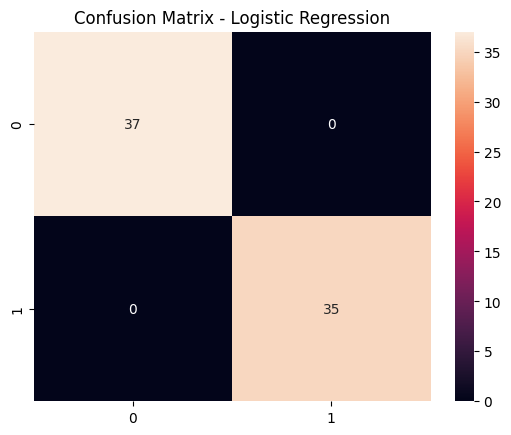

In [6]:
# Baseline model: Logistic Regression with scaling
log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression(max_iter=1000))
])

log_reg_pipeline.fit(X_train, y_train)

y_pred_lr = log_reg_pipeline.predict(X_test)

print("=== Logistic Regression (Baseline) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


**Cross-Validation for Both Models**

In [7]:
# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation for Logistic Regression
cv_scores_lr = cross_val_score(log_reg_pipeline, X, y, cv=cv, scoring="accuracy")
print("Logistic Regression CV Accuracy: ", cv_scores_lr.mean().round(4), "+/-", cv_scores_lr.std().round(4))

# Cross-validation for Random Forest (using your existing 'model')
cv_scores_rf = cross_val_score(RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
), X, y, cv=cv, scoring="accuracy")

print("Random Forest CV Accuracy: ", cv_scores_rf.mean().round(4), "+/-", cv_scores_rf.std().round(4))


Logistic Regression CV Accuracy:  0.9958 +/- 0.0083
Random Forest CV Accuracy:  1.0 +/- 0.0


**Hyperparameter Tuning for Random Forest Classifier**

In [8]:
# Hyperparameter tuning for Random Forest using RandomizedSearchCV
rf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

best_rf = random_search.best_estimator_

Best parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best CV score: 1.0


**Evaluate Model**


=== Tuned Random Forest ===
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00        35

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72



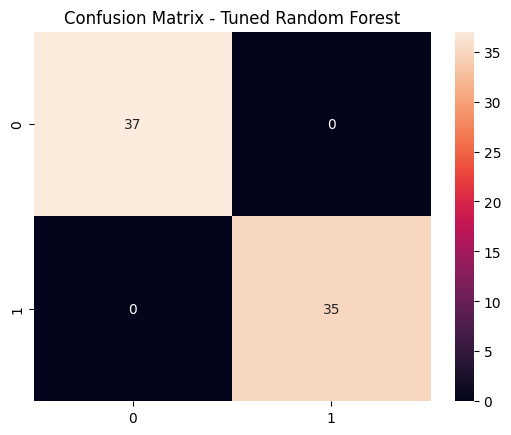

In [9]:
# Evaluate tuned model on test set
y_pred_best = best_rf.predict(X_test)

print("\n=== Tuned Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt="d")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

**ROC Curve + AUC (for RF and Logistic Regression)**

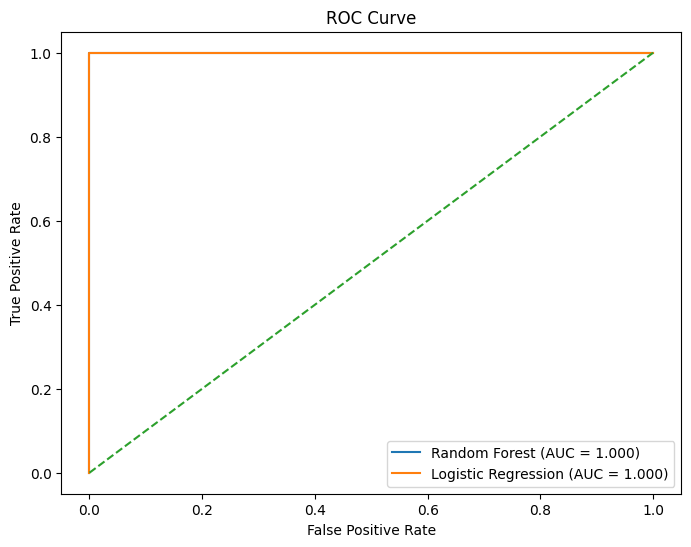

In [10]:
# Predicted probabilities (class 1) for ROC/AUC
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]
y_proba_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

# ROC curve for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

# ROC curve for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.3f})")
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_lr:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


**Consumer Behavior Visualizations**



*   Purchase rate by gender
*   Purchase rate by income



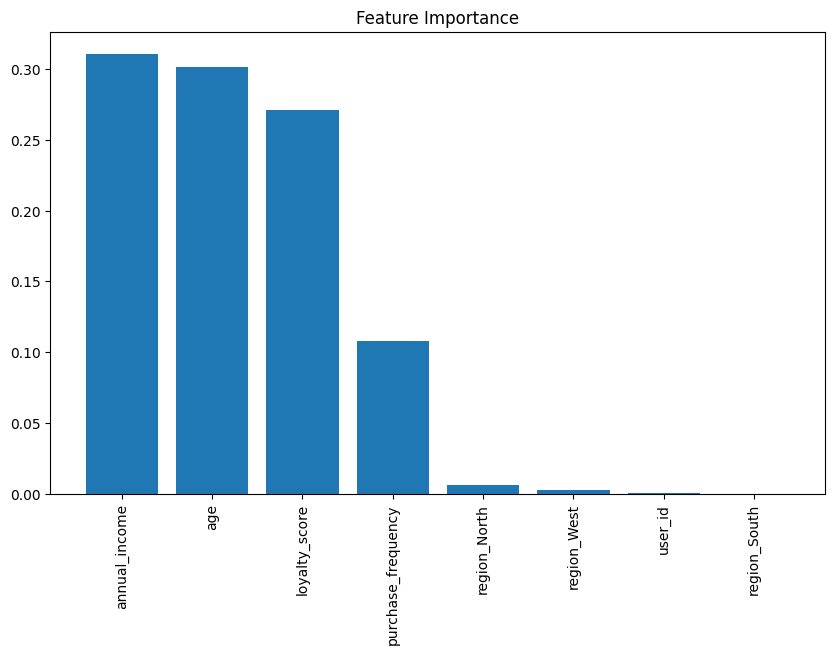

In [11]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Get the number of features available to avoid shape mismatch
num_features = len(importances)

plt.figure(figsize=(10,6))
plt.title("Feature Importance")
# Plotting all available features
plt.bar(range(num_features), importances[indices])
plt.xticks(range(num_features), X.columns[indices], rotation=90)
plt.show()

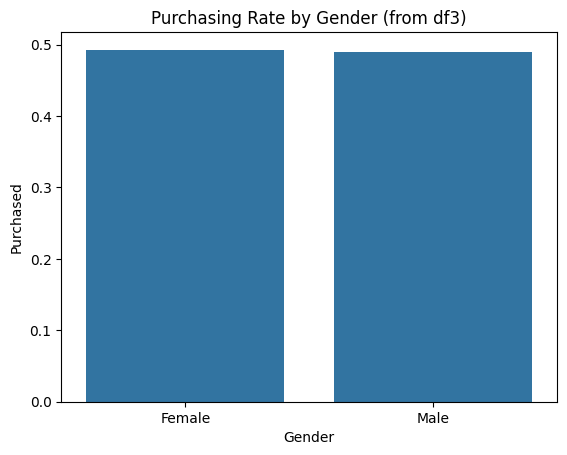

In [12]:
# Calculate 'Purchased' for df3 based on its 'Purchase Amount (USD)'
median_purchase_amount_df3 = df3['Purchase Amount (USD)'].median()
df3['Purchased'] = (df3['Purchase Amount (USD)'] > median_purchase_amount_df3).astype(int)

# Calculate purchasing rate by gender
purchasing_rate_by_gender = df3.groupby('Gender')['Purchased'].mean().reset_index()

sns.barplot(data=purchasing_rate_by_gender, x="Gender", y="Purchased")
plt.title("Purchasing Rate by Gender (from df3)")
plt.show()

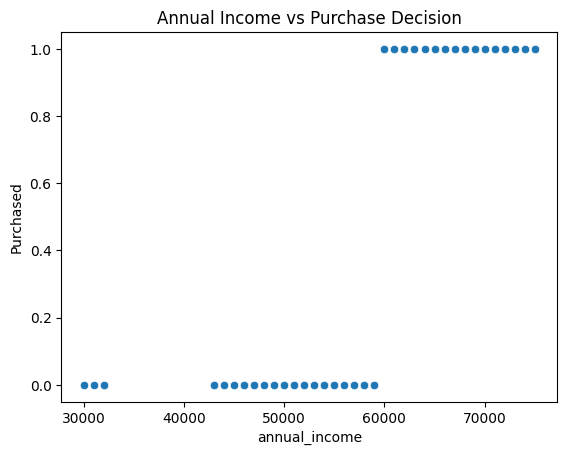

In [13]:
sns.scatterplot(data=df_clean, x="annual_income", y="Purchased")
plt.title("Annual Income vs Purchase Decision")
plt.show()

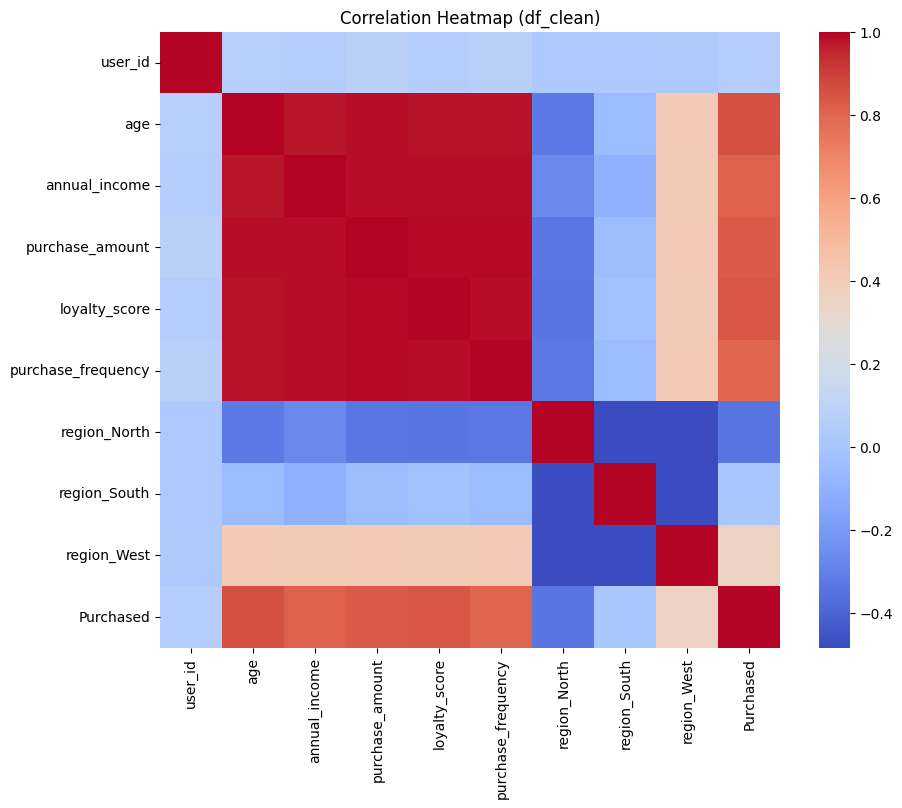

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap (df_clean)")
plt.show()

**Save Your Final Model (Deployment-Ready)**

In [15]:
# Save tuned model
joblib.dump(best_rf, "customer_purchase_random_forest.pkl")

# Example of loading it later
loaded_model = joblib.load("customer_purchase_random_forest.pkl")
sample_pred = loaded_model.predict(X_test[:5])
print("Sample predictions from loaded model:", sample_pred)

Sample predictions from loaded model: [1 0 1 1 0]


**Simple Error Analysis (Which Customers Are Misclassified?)**

In [16]:
# Error analysis using best_rf
y_pred_final = best_rf.predict(X_test)

results_df = X_test.copy()
results_df["true_label"] = y_test.values
results_df["predicted_label"] = y_pred_final
results_df["correct"] = results_df["true_label"] == results_df["predicted_label"]

print("First few misclassified examples:")
misclassified = results_df[results_df["correct"] == False]
misclassified.head()


First few misclassified examples:


,user_id,age,annual_income,loyalty_score,purchase_frequency,region_North,region_South,region_West,true_label,predicted_label,correct
